In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.spatial.distance import pdist

import sys
sys.path.append("../../..")

from gob.benchmarks import *
from gob.optimizers import *
from gob import augment_dimensions
import matplotlib
matplotlib.rcParams.update({"text.usetex": True})

In [2]:
class VisualWrapper:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.samples = []
    self.values = []
    self.prev_sample = None
  
  def __call__(self, x):
    y = self.func(x)
    if self.prev_sample is None or not np.all(np.abs(x - self.prev_sample) <= 2e-9):
      self.samples.append(x)
      self.values.append(y)
    self.prev_sample = x
    return y

  def visualize(self):
    
    x_min, x_max = self.visual_bounds[0, :]
    y_min, y_max = self.visual_bounds[1, :]
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    zz = np.array([[self.func(np.array([x, y])) for x in np.linspace(x_min, x_max, 100)] for y in np.linspace(y_min, y_max, 100)])

    _ = plt.figure(1)
    ax = plt.axes(projection="3d", computed_zorder=False)
    ax.plot_surface(xx, yy, zz, linewidth=0.2, edgecolors="white", cmap="coolwarm", zorder=0)

    samples = np.array(self.samples)
    values = np.array(self.values)
    ax.scatter(samples[:, 0], samples[:, 1], values, c=values, cmap="viridis", zorder=1)
    ax.set_box_aspect(None, zoom=0.8)

  def cum_coverage(self, n_iter, n_particles, radius=0.1):
    n_iter += 1
    d = self.samples[0].shape[0]
    if len(self.samples) <= n_iter * n_particles:
      # copy the last element until we have enough samples to visualize
      samples = self.samples + [self.samples[-1]] * (n_iter * n_particles - len(self.samples))
    elif len(self.samples) > n_iter * n_particles:
      samples = self.samples[:n_iter * n_particles]
    samples = np.array(samples)
    samples = samples.reshape(-1, n_particles, d)

    x_min, x_max = self.visual_bounds[0, :]
    y_min, y_max = self.visual_bounds[1, :]

    x_centers = np.arange(x_min + radius, x_max, 2 * radius)
    y_centers = np.arange(y_min + radius, y_max, 2 * radius)
    n_cells = len(x_centers) * len(y_centers)

    # For each particle position, find which cell it falls into
    # by snapping to the nearest grid center (i.e. floor division)
    def pos_to_cell(positions):
        """positions: (n_particles, 2) -> set of (ix, iy) cell indices"""
        ix = np.floor((positions[:, 0] - x_min) / (2 * radius)).astype(int)
        iy = np.floor((positions[:, 1] - y_min) / (2 * radius)).astype(int)
        # Clip to valid range
        ix = np.clip(ix, 0, len(x_centers) - 1)
        iy = np.clip(iy, 0, len(y_centers) - 1)
        return set(zip(ix.tolist(), iy.tolist()))

    n_iter = samples.shape[0]
    visited = set()
    cumulative_coverage = np.zeros(n_iter)

    for t in range(n_iter):
        new_cells = pos_to_cell(samples[t])  # cells visited at iteration t
        visited |= new_cells                  # union with previously visited cells
        cumulative_coverage[t] = len(visited) / n_cells

    return cumulative_coverage, visited

  def show_visited_space(self, visited, radius=0.1, legend=False):
    x_min, x_max = self.visual_bounds[0, :]
    y_min, y_max = self.visual_bounds[1, :]

    x_centers = np.arange(x_min + radius, x_max, 2 * radius)
    y_centers = np.arange(y_min + radius, y_max, 2 * radius)

    visited_space = []
    for i in range(len(x_centers)):
      for j in range(len(y_centers)):
        cell_center = (x_centers[i], y_centers[j])
        if (i, j) in visited:
            visited_space.append(cell_center)
    visited_space = np.array(visited_space)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.scatter(visited_space[:, 0], visited_space[:, 1], color="#d1dae9", s=0.5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if legend:
      rect = plt.Rectangle((0, 0), 0, 0, color="#d1dae9", label="visited space")
      ax.add_patch(rect)
      ax.legend()
    
  def visualize_distance(self, n_iter, n_particles):
    n_iter += 1
    d = self.samples[0].shape[0]
    if len(self.samples) <= n_iter * n_particles:
      # copy the last element until we have enough samples to visualize
      samples = self.samples + [self.samples[-1]] * (n_iter * n_particles - len(self.samples))
    elif len(self.samples) > n_iter * n_particles:
      samples = self.samples[:n_iter * n_particles]
    samples = np.array(samples)
    samples = samples.reshape(-1, n_particles, d)

    # Calcul de la distance max à chaque itération
    def compute_metrics(samples):
        max_dist = np.array([
            pdist(samples[t]).max()
            for t in range(n_iter)
        ])
        variance = np.std(samples, axis = (1, 2))
        return max_dist, variance

    max_dist, var = compute_metrics(samples)
    mean_dist = np.array([pdist(samples[t]).mean() for t in range(n_iter)])
    return max_dist, mean_dist, var
  
  def plot_min(self, n_iter, legend=False):
    n_iter += 1
    if len(self.values) <= n_iter:
      # copy the last element until we have enough samples to visualize
      values = self.values + [self.values[-1]] * (n_iter - len(self.samples))
    elif len(self.values) > n_iter:
      values = self.values[-n_iter:]
    values = np.array(values)
    min_val = np.inf
    min_values = []
    for t in range(n_iter):
      min_val = min(min_val, values[t])
      min_values.append(min_val)
    print(np.min(min_values))
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.plot(min_values, label="min value", c="#3a4cc0")
    ax.set_ylim(-0.5, 20.5)
    if legend:
      ax.legend()
  
  def visualize_density(self, n_iter, n_particles, t, legend=False):
    n_iter += 1
    d = self.samples[0].shape[0]
    if len(self.samples) <= n_iter * n_particles:
      # copy the last element until we have enough samples to visualize
      samples = self.samples + [self.samples[-1]] * (n_iter * n_particles - len(self.samples))
    elif len(self.samples) > n_iter * n_particles:
      samples = self.samples[:n_iter * n_particles]
    samples = np.array(samples)
    samples = samples.reshape(-1, n_particles, d)[t]
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    x_min, x_max = self.visual_bounds[0, :]
    x_min -= 1
    x_max += 1
    y_min, y_max = self.visual_bounds[1, :]
    y_min -= 1
    y_max += 1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Contours de la fonction objectif (arrière-plan)
    f_vec = np.vectorize(lambda xi, yi: self.func(np.array([xi, yi])))
    Z_obj = f_vec(XX, YY)
    ax.contour(XX, YY, Z_obj, levels=20, cmap='Greys', alpha=0.5)

    x, y = samples[:, 0], samples[:, 1]
    
    # Estimation de la densité par noyau (KDE)
    kde = gaussian_kde(samples.T, bw_method='scott')
    
    # Grille d'évaluation
    x_grid = np.linspace(x_min, x_max, 200)
    y_grid = np.linspace(y_min, y_max + 1, 200)
    XX, YY = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([XX.ravel(), YY.ravel()])

    
    # Évaluation de la densité sur la grille
    Z = kde(positions).reshape(XX.shape)
    
    # Plot
    ax.contourf(XX, YY, Z, levels=20, cmap='coolwarm')
    ax.scatter(x, y, c='red', s=10, alpha=0.5, label='particles')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if legend:
      ax.legend()

In [3]:
class Holder:
  visual_bounds = np.array([[-10, 10], [-10, 10]])
  
  def __call__(self, x):
    x1, x2 = x
    return -np.abs(np.sin(x1) * np.cos(x2) * np.exp(np.abs(1 - np.sqrt(x1**2 + x2**2) / np.pi)))

In [4]:
n_particles = 15
iter = 1000
snapshot = 999
fun = Ackley()
f_ = lambda : VisualWrapper(fun)
bounds = augment_dimensions(fun.visual_bounds, 2)
opt_ = Langevin
smd_opt = SMD_Langevin
gcn_opt = GCN_Langevin
dt = 0.1

opt_str = str(opt_([]))
smd_opt_str = "SMD-" + opt_str
gcn_opt_str = "GCN-" + opt_str

Results for Langevin: 0.23789033118993475


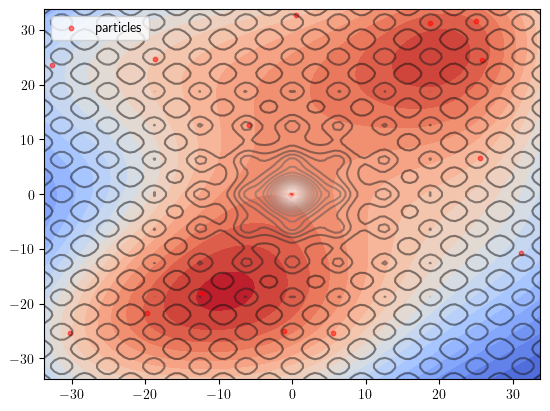

In [23]:
f = f_()

sigma = 1 / n_particles**2
verbose = False

opt = opt_(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot, True)
plt.savefig("exploration_opt.svg", bbox_inches="tight")

In [24]:
opt_max, opt_mean, opt_var = f.visualize_distance(iter, n_particles)

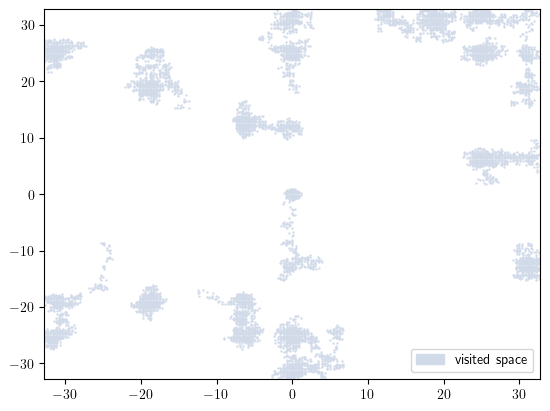

In [25]:
opt_coverage, visited = f.cum_coverage(iter, n_particles)
f.show_visited_space(visited, legend=True)
plt.savefig("exploration_visited_opt.svg", bbox_inches="tight")

0.3003952927048599


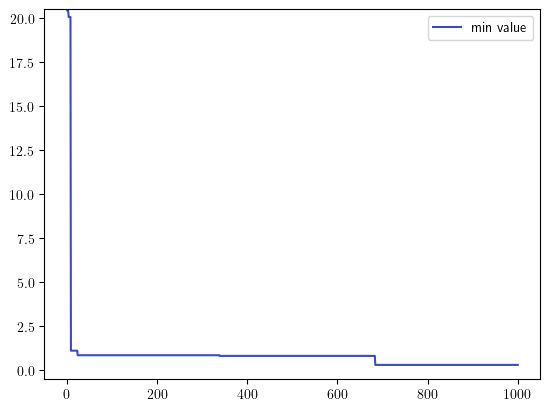

In [26]:
f.plot_min(iter, True)
plt.savefig("exploration_opt_min.svg", bbox_inches="tight")

Results for SMD-Langevin: 0.061681525643465296


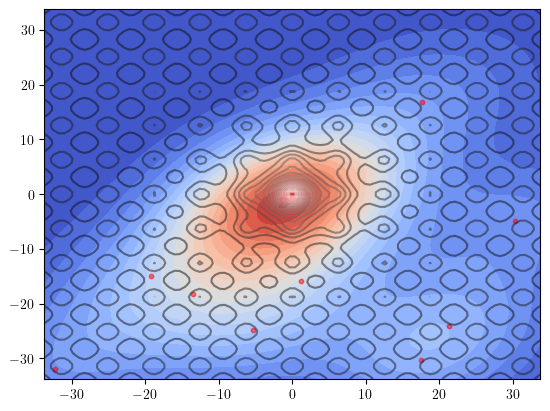

In [34]:
f = f_()

sigma = 1 / n_particles**2
verbose = False

opt = smd_opt(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt,
              moment="MVAR", gamma=1)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot)
plt.savefig("exploration_smd_opt.svg", bbox_inches="tight")

In [35]:
smd_opt_max, smd_opt_mean, smd_opt_var = f.visualize_distance(iter, n_particles)

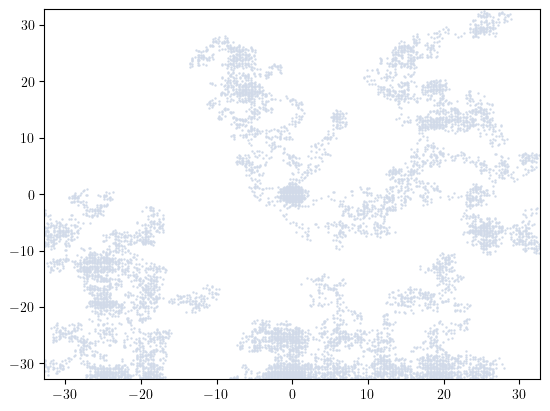

In [36]:
smd_opt_coverage, visited = f.cum_coverage(iter, n_particles)
f.show_visited_space(visited)
plt.savefig("exploration_visited_smd_opt.svg", bbox_inches="tight")

0.3025976170503424


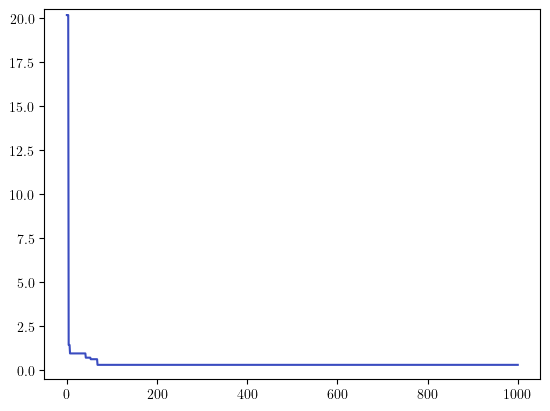

In [37]:
f.plot_min(iter)
plt.savefig("exploration_smd_opt_min.svg", bbox_inches="tight")

Results for GCN-Langevin: 0.16740861768794035


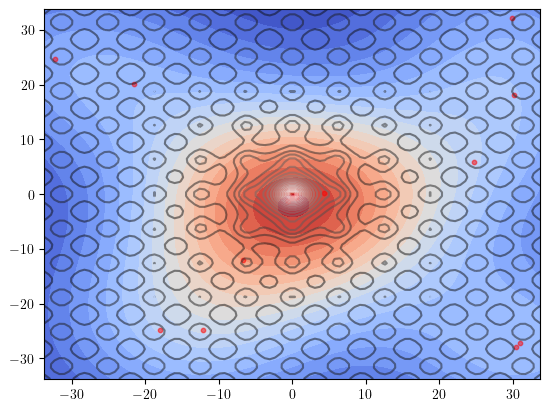

In [38]:
f = f_()

sigma = 1 / n_particles**2
verbose = False

opt = gcn_opt(bounds=bounds, n_particles=n_particles, iter=iter, verbose=verbose, dt=dt)
res = opt.minimize(f)
print(f"Results for {opt}: {res[1]}")
f.visualize_density(iter, n_particles, snapshot)
plt.savefig("exploration_gcn_opt.svg", bbox_inches="tight")

In [39]:
gcn_opt_max, gcn_opt_mean, gcn_opt_var = f.visualize_distance(iter, n_particles)

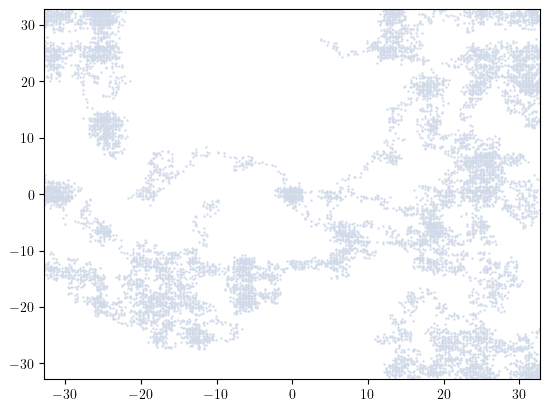

In [40]:
gcn_opt_coverage, visited = f.cum_coverage(iter, n_particles)
f.show_visited_space(visited)
plt.savefig("exploration_visited_gcn_opt.svg", bbox_inches="tight")

0.37454319491924837


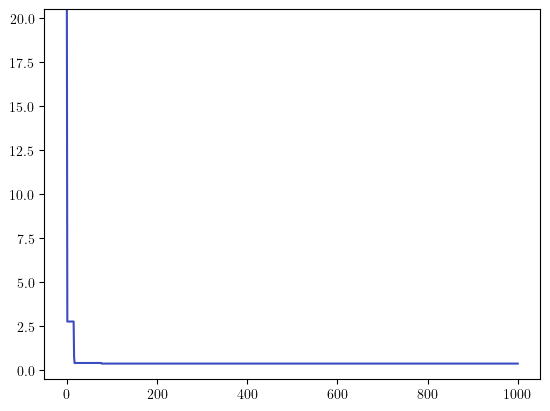

In [41]:
f.plot_min(iter)
plt.savefig("exploration_gcn_opt_min.svg", bbox_inches="tight")

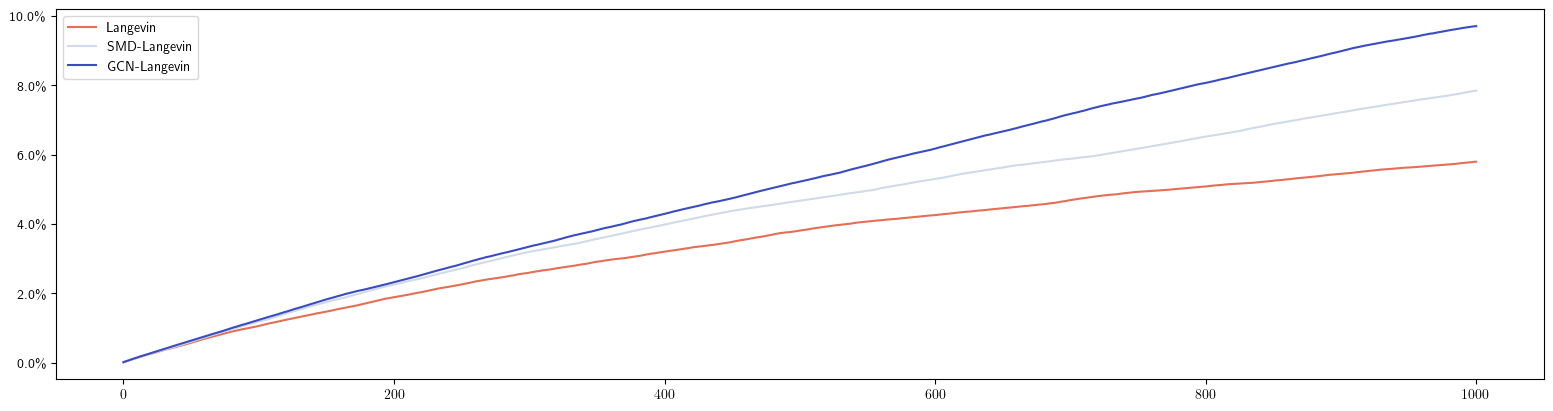

In [42]:
import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(19.2, 4.8))
ax.plot(opt_coverage * 100, label=opt_str, c="#e46e56")
ax.plot(smd_opt_coverage * 100, label=smd_opt_str, c="#d1dae9")
ax.plot(gcn_opt_coverage * 100, label=gcn_opt_str, c="#3a4cc0")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.savefig("exploration_coverage.svg", bbox_inches="tight")

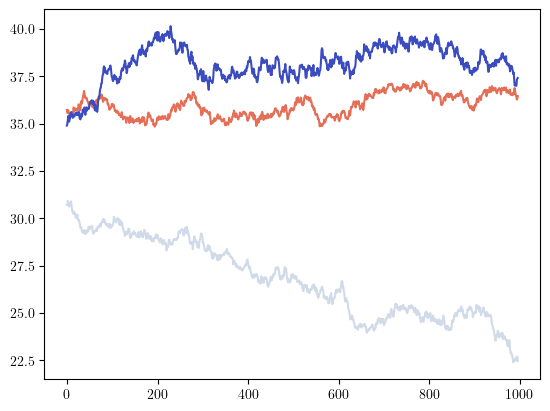

In [18]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(opt_mean[2:998], label=opt_str, c="#e46e56")
ax.plot(smd_opt_mean[2:998], label=smd_opt_str, c="#d1dae9")
ax.plot(gcn_opt_mean[2:998], label=gcn_opt_str, c="#3a4cc0")
#plt.savefig("exploration_mean.svg", bbox_inches="tight")

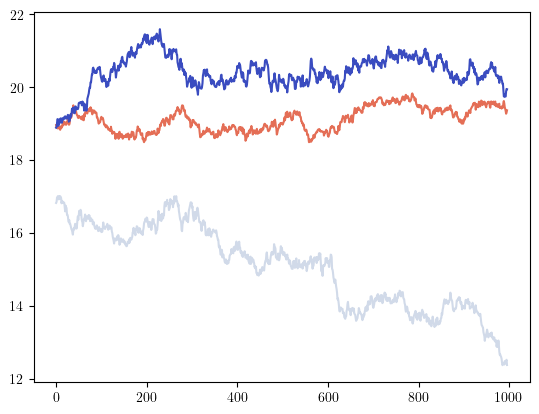

In [19]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(opt_var[2:998], label=opt_str, c="#e46e56")
ax.plot(smd_opt_var[2:998], label=smd_opt_str, c="#d1dae9")
ax.plot(gcn_opt_var[2:998], label=gcn_opt_str, c="#3a4cc0")
# ax.legend()
#plt.savefig("exploration_var.svg", bbox_inches="tight")

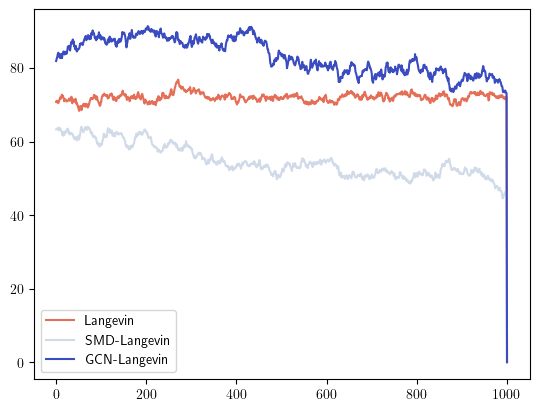

In [20]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(opt_max, label=opt_str, c="#e46e56")
ax.plot(smd_opt_max, label=smd_opt_str, c="#d1dae9")
ax.plot(gcn_opt_max, label=gcn_opt_str, c="#3a4cc0")
ax.legend()
#plt.savefig("exploration_max.svg", bbox_inches="tight")

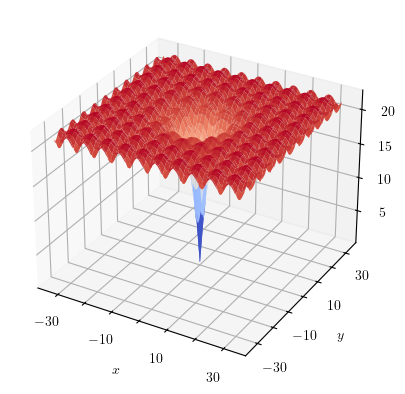

In [21]:
ben = f.func
bounds = ben.visual_bounds
x = np.linspace(bounds[0][0], bounds[0][1], 500)
y = np.linspace(bounds[1][0], bounds[1][1], 500)
X, Y = np.meshgrid(x, y)
Z = np.array(
    [ben(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))]
).reshape(X.shape)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, cmap="coolwarm")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_box_aspect(None)
xticks = ax.xaxis.get_major_ticks()
yticks = ax.yaxis.get_major_ticks()
for i in range(0, len(xticks), 2):
    xticks[i].label1.set_visible(False)
for i in range(0, len(yticks), 2):
    yticks[i].label1.set_visible(False)
#plt.savefig("exploration_func.svg", bbox_inches="tight")